# 3D With hubble sphere = 0.30
Best fit curve when we define a maximum range where planets can occupy other planets. I believe I = 0.30 here

In [6]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=1,hb=5.0.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24

print(t1)
print(k1)




[ 11.47113287  19.41473972  33.89555198  31.53450169  33.15674449
  45.577392    83.77953443  83.05190716 140.8697129  294.96856241
 565.0864044 ]
[0.         0.1        0.2        0.30000001 0.40000001 0.5
 0.60000002 0.69999999 0.80000001 0.89999998 0.94999999]


R^2 score: 0.9979


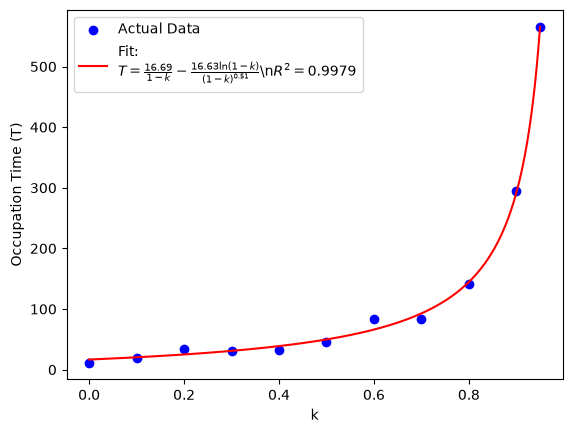

In [6]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

R^2 score: 0.9995


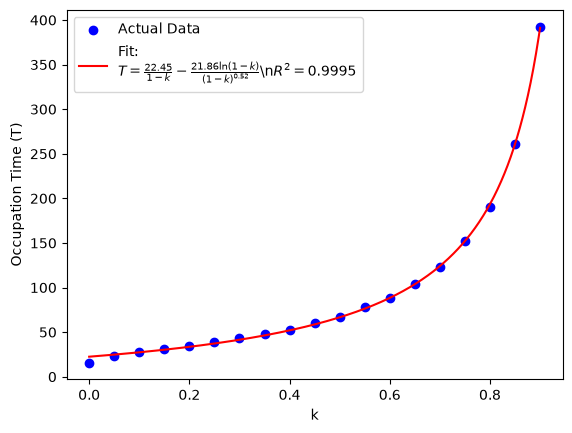

In [17]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# holding the D_fit parameter to be the time at k=0

R^2 score: 0.9978


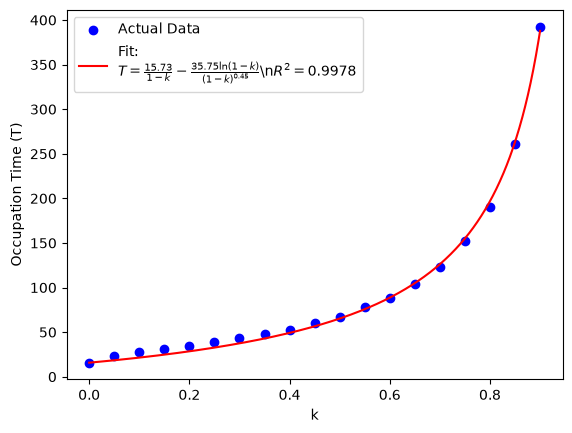

In [18]:
D = 15.73417052
# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [33, 1.0]
popt, _ = curve_fit(occupation_time, k1, t1, p0=p0)
beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(k1, t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.show()

# Applied with OCTANT ENCLOSURE

In [5]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("sims=10,k=vary, type=octant_enclosed.dat")
enclosed_k1 = data1[:, 0]
enclosed_t1 = data1[:, 1]
# D_o = data1[0, 1]
beta = 32.24
print(enclosed_t1)
print(enclosed_k1)


[ 28.56684193  34.37271532  46.34052689  52.70667152  67.15321922
  67.15321922  92.05776186  92.05776186 120.57586314 211.23518745
 391.54521732  18.64788453  18.64788453]
[0.1        0.2        0.30000001 0.40000001 0.5        0.5
 0.60000002 0.60000002 0.69999999 0.80000001 0.89999998 0.
 0.        ]


R^2 score: -14.4769


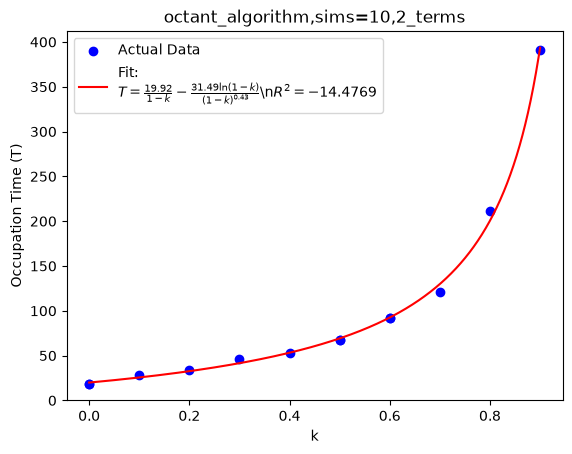

In [6]:

# 1. Define the 3-parameter Logistic Growth Model
def occupation_time(k,D,beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)


# Fit curve
p0 = [10,33, 1.0]
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=p0)
D_fit, beta_fit, gamma_fit = popt


# --- Calculate Coefficient of Determination (R^2) ---
t1_pred = occupation_time(k1, *popt)
ss_res = np.sum((t1 - t1_pred) ** 2)  # Residual sum of squares
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)  # Total sum of squares
r2 = 1 - (ss_res / ss_tot)  # R^2 score
6
print(f"R^2 score: {r2:.4f}")

# Label including R^2
eq_label = (
    rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
    rf"\frac{{{float(beta_fit):.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
    rf"\n$R^2 = {r2:.4f}$"
)

k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, *popt)

# Plot
plt.scatter(enclosed_k1, enclosed_t1, label="Actual Data", color="blue")
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red")
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.title("octant_algorithm,sims=10,2_terms")
plt.legend()
plt.show()

# Dropping the 2nd term in the octant algorithm

Fitted D: 38.4311
R^2 score: 0.9862


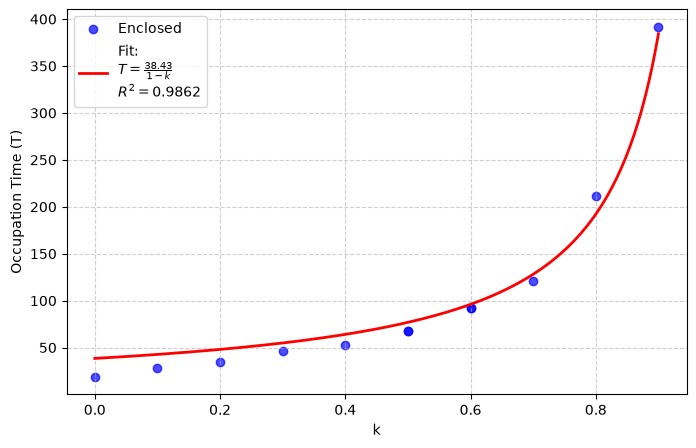

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, enclosed_k1, enclosed_t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(enclosed_k1, D_fit)
ss_res = np.sum((enclosed_t1 - t1_pred) ** 2)
ss_tot = np.sum((enclosed_t1 - np.mean(enclosed_t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(enclosed_k1), max(enclosed_k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"

plt.figure(figsize=(8, 5))
plt.scatter(enclosed_k1, enclosed_t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# 3D Version. max_range = 0.90, k = vary, sims = 500
I put a maximum range to where planets can reach other planets.


Fitted D: 10.4192
R^2 score: 0.9996


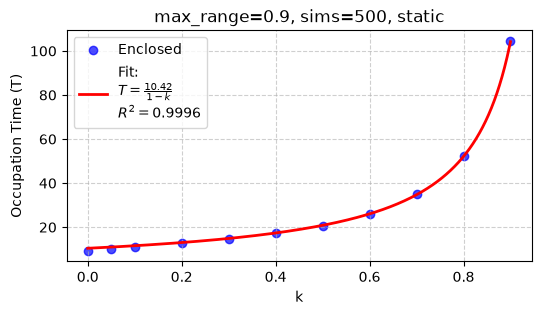

In [2]:
###### from math import log
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=500,hb=0.9.dat")
k1 = data1[:, 0]
t1 = data1[:, 1]
t_de = data1[:,2]
t_m = data1[:,3]

# Model fitting D with beta = 0
def occupation_time(k, D_fit):
    return D_fit / (1.0 - k)

# Fit curve to find optimal D
popt, _ = curve_fit(occupation_time, k1, t1, p0=[18.0])
D_fit = popt[0]

# Predictions and R^2
t1_pred = occupation_time(k1, D_fit)
ss_res = np.sum((t1 - t1_pred) ** 2)
ss_tot = np.sum((t1 - np.mean(t1)) ** 2)
r2 = 1.0 - (ss_res / ss_tot)

print(f"Fitted D: {D_fit:.4f}")
print(f"R^2 score: {r2:.4f}")

# Plotting
k_dense = np.linspace(min(k1), max(k1), 1000)
t_fit = occupation_time(k_dense, D_fit)

eq_label = rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}}$" + f"\n$R^2 = {r2:.4f}$"

plt.figure(figsize=(6,3))
plt.scatter(k1, t1, label="Enclosed", color="blue", alpha=0.7)
plt.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)
plt.xlabel("k")
plt.ylabel("Occupation Time (T)")
plt.legend()
plt.title("max_range=0.9, sims=500, static")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



--- Fit for $t_s$ ---
D = 9.7117, beta = 1.3292, gamma = 0.3771
R^2 = 0.9999

--- Fit for $t_{de}$ ---
D = 15.5489, beta = -29.0359, gamma = -0.8410
R^2 = 0.9932

--- Fit for $t_m$ ---
D = 10.2439, beta = 0.5707, gamma = 1.3884
R^2 = 0.9999



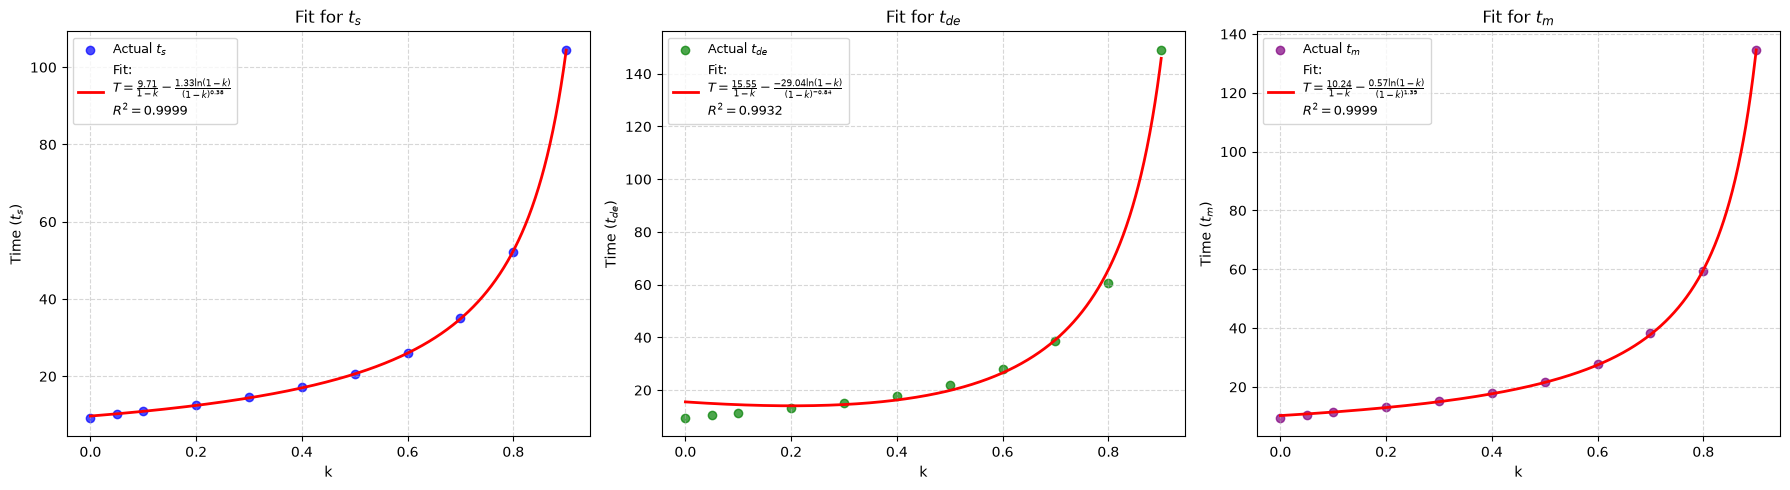

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load data
data1 = np.loadtxt("3D_with_enclosure_static,curve,k=vary,sims=500,hb=0.9.dat")
k1 = data1[:, 0]
targets = {
    "$t_s$": data1[:, 1],
    "$t_{de}$": data1[:, 2],
    "$t_m$": data1[:, 3],
}

# Define the 3-parameter model
def occupation_time(k, D, beta, gamma):
    return D / (1 - k) - beta * np.log(1 - k) / ((1 - k) ** gamma)

# Dense k array for smooth curve plotting
k_dense = np.linspace(min(k1), max(k1), 1000)

# Setup subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Colors for each subplot
colors = ["blue", "green", "purple"]
initial_p0 = [10, 33, 1.0]

for ax, (name, y_data), color in zip(axes, targets.items(), colors):
    # Fit curve
    popt, _ = curve_fit(occupation_time, k1, y_data, p0=initial_p0)
    D_fit, beta_fit, gamma_fit = popt

    # Calculate R^2
    y_pred = occupation_time(k1, *popt)
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Print fitted parameters
    print(
        f"--- Fit for {name} ---\n"
        f"D = {D_fit:.4f}, beta = {beta_fit:.4f}, gamma = {gamma_fit:.4f}\n"
        f"R^2 = {r2:.4f}\n"
    )

    # Generate equation label
    eq_label = (
        rf"$T = \frac{{{D_fit:.2f}}}{{1 - k}} - "
        rf"\frac{{{beta_fit:.2f} \ln(1 - k)}}{{(1 - k)^{{{gamma_fit:.2f}}}}}$"
        f"\n$R^2 = {r2:.4f}$"
    )

    # Plot data and best fit
    t_fit = occupation_time(k_dense, *popt)
    ax.scatter(k1, y_data, label=f"Actual {name}", color=color, alpha=0.7)
    ax.plot(k_dense, t_fit, label=f"Fit:\n{eq_label}", color="red", linewidth=2)

    ax.set_xlabel("k")
    ax.set_ylabel(f"Time ({name})")
    ax.set_title(f"Fit for {name}")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 3D with max range = 0.90, sims = 500
Here we get the best fit curve for 500 simulations of the max range enclosure.


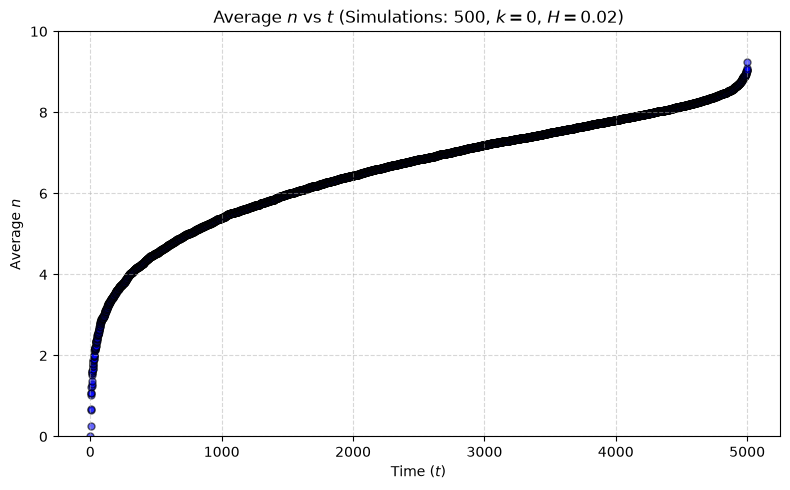

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the .dat file
file_path = "average_n_vs_t,sims=500,k=0,H=0.02.dat"
# Using engine='python' avoids regex separator warnings in newer pandas versions
df = pd.read_csv(file_path, header=None, sep=r"\s+", engine="python")

# Extract columns (Column 0 as X, Column 1 as Y)
x = df[0]
y = df[1]

# Create a clean figure layout
plt.figure(figsize=(8, 5))

# Use scatter instead of plot to get actual scatter points
plt.scatter(x, y, color="blue", edgecolor="black", alpha=0.6, s=25)

# Set axes limits dynamically or strictly as you defined
plt.ylim(0, 10)

# Add descriptive titles and labels parsed from your file metadata
plt.title("Average $n$ vs $t$ (Simulations: 500, $k=0$, $H=0.02$)")
plt.xlabel("Time ($t$)")
plt.ylabel("Average $n$")

# Improve grid aesthetics with dashed lines
plt.grid(True, linestyle="--", alpha=0.5)

# Optimize spacing and display
plt.tight_layout()
plt.show()
